# 01. 횡단면 전처리는 날짜 안에서 끝난다

> 2026-09-09 · 이동원 · 팀장 지정 주제 *"전처리·정제·마이닝 — 수업에서 배운 심화 부분"* ·
> 코드: [`features/preprocessing.py`](../../features/preprocessing.py) ·
> 결론 문서: [전처리 v1.1](../../docs/전처리/version1.1/전처리-설계-명세서.md)

퀀트가 피처를 모델에 넣기 전에 거치는 표준 전처리는 네 단계이고 순서가 있습니다.

| | 단계 | 무엇 | 우리 코드 (09-09 아침) |
|---|---|---|---|
| ① | winsorize | 극단값을 그날 횡단면 기준으로 **당긴다** | ❌ 없음 |
| ② | z-score | 그날 평균·표준편차로 표준화 | ❌ 없음 (시계열 방향 `StandardScaler` 만 Pipeline 안에) |
| ③ | 중립화 | 업종·시총 축에 회귀해 잔차만 | ❌ 없음 |
| ④ | rank | 그날 순위로 | 🟡 일부 (`ret_5_rank` 등 5칸 · #155 조합 F) |

이 노트북은 **실제 학습 패널**(오준영 님이 쓰시는 `load_stock_model_dataset` 정본 경로 ·
업종 10 × 종목 5 후보군)에 네 단계를 걸고, 단계마다 **무엇이 얼마나 바뀌는지를 그림으로**
보입니다. 수업 07단원 3·10번(스케일링·VIF), 09단원 1·2번(금융 전처리)에서 배운 것을 우리
자료에 맞대는 것이 목적이고, 숫자는 전부 이 노트북이 실행하며 낸 것입니다.

순서:

1. 패널 — 무엇 위에서 재는가
2. 결측 — 어디에 있고, 왜 채우지 않는가 · 코드 재사용이 만든 NaN 하나
3. 분포 — 무엇이 꼬리가 긴가
4. ① 극단값 — 분위 · 3σ · MAD 가 각각 무엇을 건드리나 → **1% 는 0.49종이다**
5. ② z-score — 날짜 안 vs 전 구간, 어디서 새는가
6. ③ 중립화 — 업종·시총이 피처를 얼마나 설명하고, IC 는 어떻게 바뀌나 → 기본 축 결정
7. ④ 순위 — uniform · gaussian · signed
8. 트리 모델에 무엇이 유효한가 — 실증
9. 정리

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from matplotlib import font_manager
from matplotlib.ticker import FuncFormatter, NullFormatter
from sklearn.ensemble import RandomForestClassifier

ROOT = Path.cwd()
while not (ROOT / "supply").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import scripts.run_stock_model_experiment as exp                          # noqa: E402, I001
from features import preprocessing as P                                   # noqa: E402
from features.stock_model_dataset import ALL_STOCK_FEATURE_COLUMNS         # noqa: E402

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.4f}".format)


def 한글폰트_설정() -> str:
    """한글 폰트를 잡고 **깨짐을 막는다.** 세 가지를 다 해야 안 깨진다.

    ① **한글 폰트** — 없으면 제목·축이름이 전부 □ 로 나온다.
    ② **fallback 체인** — 맑은 고딕에는 U+2212(−)가 **없다**(실측). 로그 축의 10⁻³ 은
       mathtext 로 그려지고 거기서 두부가 났다. `font.family` 에 리스트를 주면
       matplotlib(3.6+)이 앞에서부터 찾다가 없는 글자만 뒤 폰트에서 가져온다.
       DejaVu Sans 에는 U+2212 가 있고 한글은 없으니, 둘이 서로를 채운다.
    ③ `axes.unicode_minus = False` — 일반 축 눈금의 마이너스를 ASCII 하이픈으로.
       mathtext(로그 지수)에는 이 설정이 안 먹으므로 ② 가 따로 필요하다.
    """
    후보 = ["Malgun Gothic", "NanumGothic", "NanumBarunGothic", "AppleGothic",
            "Noto Sans CJK KR", "Gulim"]
    있는것 = {f.name for f in font_manager.fontManager.ttflist}
    찾음 = next((n for n in 후보 if n in 있는것), None)
    if 찾음 is None:
        print("🔴 한글 폰트가 없다 — 그림의 한글이 □ 로 나온다. 할 일:\n"
              "   Colab·Linux : !apt-get install -y fonts-nanum && fc-cache -fv\n"
              "                 그 뒤 런타임 재시작 (matplotlib 이 폰트 목록을 캐시한다)\n"
              "   Windows     : 맑은 고딕은 기본 설치다. 캐시가 낡았을 수 있으니\n"
              "                 python -c \"import matplotlib as m; print(m.get_cachedir())\"\n"
              "                 가 찍는 폴더를 지우고 다시 실행한다")
        return "(없음)"
    plt.rcParams["font.family"] = [찾음, "DejaVu Sans"]   # ②
    plt.rcParams["axes.unicode_minus"] = False            # ③
    return 찾음


def 로그축_ASCII(ax, axis: str = "x") -> None:
    """로그 축 눈금을 `0.001` 처럼 **그냥 쓴다.**

    🔴 위 ②③ 으로도 **로그 축만은 안 고쳐진다.** matplotlib 은 로그 눈금을
    mathtext(`$10^{-3}$`)로 그리는데, mathtext 는 `font.family` 체인을 따르지 않아
    맑은 고딕에서 U+2212 자리가 □ 가 된다(`Font 'default' does not have a glyph`).
    `mathtext.fontset` 을 바꿔도 그대로였다 — 네 조합을 실제로 그려 확인했다.

    그래서 표기를 바꾼다. 값이 작은 범위면 `10⁻³` 보다 `0.001` 이 읽기도 쉽다.
    """
    축 = ax.xaxis if axis == "x" else ax.yaxis
    축.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    축.set_minor_formatter(NullFormatter())


폰트 = 한글폰트_설정()
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["grid.color"] = "#e1e0d9"
plt.rcParams["axes.edgecolor"] = "#c3c2b7"

# 색 — 범주는 고정 순서(파랑·주황·청록·노랑), 강조 하나 + 회색. 상승 빨강·하락 파랑은 한국 표기.
C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
     "violet": "#4a3aa7", "red": "#e34948", "gray": "#898781", "light": "#c3c2b7"}

HF = ROOT / "data" / "raw" / "hf_snapshot" / "full" / "daily_price_dev.parquet"
t0 = time.time()
print("python", sys.version.split()[0], "· pandas", pd.__version__, "· numpy", np.__version__)
print(f"한글 폰트: {폰트} · fallback {plt.rcParams['font.family']}")

python 3.12.13 · pandas 3.0.3 · numpy 1.26.4
한글 폰트: Malgun Gothic · fallback ['Malgun Gothic', 'DejaVu Sans']


### 폰트가 제대로 잡혔는지 그림으로 확인합니다

*"실행은 됐는데 그림만 깨져 있는"* 것을 나중에 발견하면 전부 다시 그려야 합니다. 한글·마이너스
기호·로그 축 지수 셋을 한 장에 그려 **먼저** 봅니다. 셋 중 하나라도 □ 로 보이면 위 셀의 안내를
따르세요.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


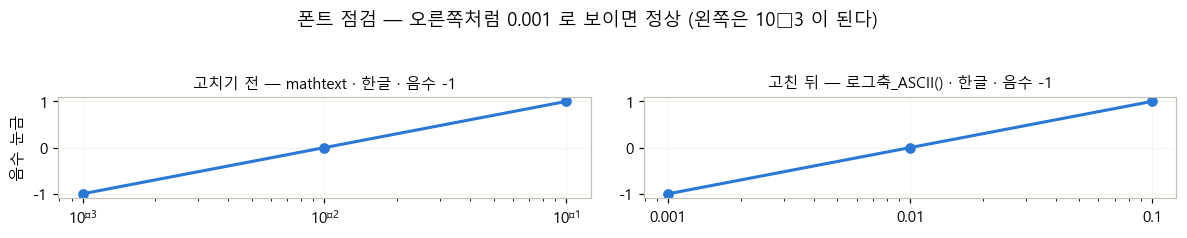

  Malgun Gothic    한글(가) O · 마이너스(U+2212) X · malgun.ttf
  DejaVu Sans      한글(가) X · 마이너스(U+2212) O · DejaVuSans.ttf
  → 둘을 체인으로 두면 서로의 빈칸을 채운다


In [2]:
from matplotlib.ft2font import FT2Font  # noqa: E402, I001

fig, axes = plt.subplots(1, 2, figsize=(11, 2.0))
for ax, 이름 in zip(axes, ["고치기 전 — mathtext", "고친 뒤 — 로그축_ASCII()"], strict=True):
    ax.plot([1e-3, 1e-2, 1e-1], [-1, 0, 1], color=C["blue"], lw=2, marker="o")
    ax.set_xscale("log")
    ax.set_title(f"{이름} · 한글 · 음수 -1", fontsize=10)
    if "고친" in 이름:
        로그축_ASCII(ax)
axes[0].set_ylabel("음수 눈금")
fig.suptitle("폰트 점검 — 오른쪽처럼 0.001 로 보이면 정상 (왼쪽은 10□3 이 된다)", y=1.06)
plt.tight_layout()
plt.show()

for 이름 in (폰트, "DejaVu Sans"):
    경로 = font_manager.findfont(font_manager.FontProperties(family=이름),
                                fallback_to_default=False)
    f = FT2Font(경로)
    print(f"  {이름:16s} 한글(가) {'O' if f.get_char_index(0xAC00) else 'X'} · "
          f"마이너스(U+2212) {'O' if f.get_char_index(0x2212) else 'X'} · "
          f"{Path(경로).name}")
print("  → 둘을 체인으로 두면 서로의 빈칸을 채운다")

## 1. 패널 — 무엇 위에서 재는가

오준영 님의 실험 스크립트가 쓰는 함수를 그대로 부릅니다. HF 반출본(`full/daily_price_dev.parquet`,
2026-09-09 재배포 · 34칸)에서 KOSPI 만 읽어 **업종 시가총액 상위 10 × 업종별 종목 상위 5** 후보를
날짜마다 고르고, `is_adj_suspect` 행만 빼고, 피처 38개와 T+1→T+6 시가 수익률 라벨을 붙입니다.

In [3]:
ds = exp.load_stock_model_dataset(ALL_STOCK_FEATURE_COLUMNS)
panel = ds.frame.copy()                                  # 모델이 보는 행 (피처 전부 유효)
base = exp._read_cached_panel(exp._panel_cache_signature()).frame.copy()   # 선택 전 · NaN
FEATS = [c for c in ALL_STOCK_FEATURE_COLUMNS if c in panel.columns]
n_by_date = base.groupby("bas_dd").size()
for 이름, df in (("선택 전 패널(캐시)", base), ("모델 표본(피처 전부 유효)", panel)):
    print(f"{이름}: {len(df):,}행 · 날짜 {df.bas_dd.nunique():,}일 "
          f"({df.bas_dd.min()}~{df.bas_dd.max()}) · 종목 {df.code.nunique()}종 "
          f"· 업종 {df.industry.nunique()}종")
print(f"날짜별 종목 수(선택 전): 최소 {n_by_date.min()} · 중앙 {int(n_by_date.median())} "
      f"· 최대 {n_by_date.max()}")
label_share = panel["label_numeric"].value_counts(normalize=True).round(4).to_dict()
print("라벨 분포(모델 표본):", label_share)
print("품질 요약:", panel.attrs.get("adjustment_quality"))
print(f"피처 {len(FEATS)}개")

선택 전 패널(캐시): 175,914행 · 날짜 3,612일 (20100104~20240822) · 종목 164종 · 업종 17종
모델 표본(피처 전부 유효): 159,936행 · 날짜 3,343일 (20110127~20240822) · 종목 157종 · 업종 17종
날짜별 종목 수(선택 전): 최소 46 · 중앙 49 · 최대 50
라벨 분포(모델 표본): {0: 0.3801, -1: 0.3187, 1: 0.3011}
품질 요약: {'gap_tolerance': 1.0, 'extreme_pct': 30.0, 'rows': 3315889, 'comparable_rows': 3314656, 'suspect_rows': 1080, 'extreme_rows': 853, 'candidate_rows': 176705, 'candidate_suspect_rows': 0, 'candidate_extreme_rows': 5, 'candidate_unmatched_rows': 0}
피처 39개


두 표가 있습니다. **선택 전 패널**은 후보 행 전부(준비구간 NaN 포함)이고, **모델 표본**은 그중
38개 피처가 전부 유효한 행입니다 — `select_stock_feature_dataset` 이 고르고, 오준영 님 실험은
이 표본 위에서 돕니다. 2절(결측)만 선택 전 패널을 보고, 3절부터는 모델 표본입니다.

날짜별 종목 수가 46~50 이라는 사실이 이 노트북의 절반을 결정합니다. **횡단면이 49개**라는 뜻이고,
4절에서 "1% 분위" 가 무엇을 뜻하는지가 여기서 갈립니다.

## 2. 결측 — 어디에 있고, 왜 채우지 않는가

수업 02단원 4장은 `fillna`·`dropna`·보간을 가르치고, 09단원 1장은 *"시계열 특성을 고려한 보간"*
을 말합니다. 우리 피처의 결측이 **어디에** 있는지부터 봅니다. 공급 계약 4(`test_supply_features_contract`)
는 *"NaN 은 앞쪽 연속구간(준비구간)에만"* 을 못박고 있습니다 — 그게 지켜지면 채울 이유가 없습니다.

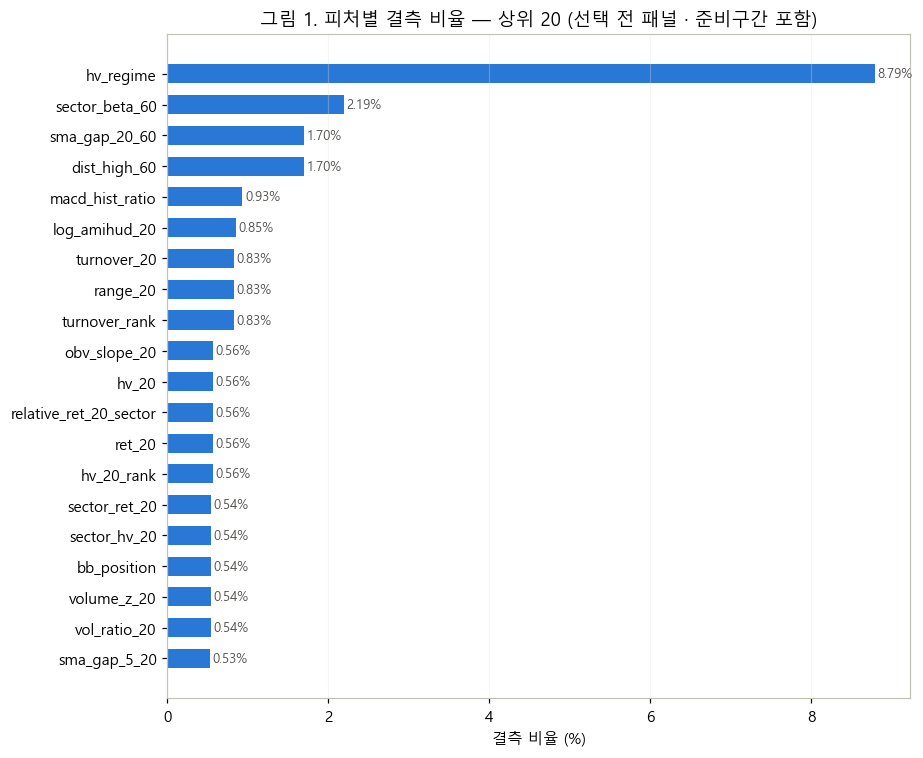

결측이 가장 많은 칸 hv_regime 도 8.79% 다. 전체 39칸 평균 0.71% · 모델 표본에서는 정의상 0%


In [4]:
miss = base[FEATS].isna().mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(8.5, 7))
top = miss.head(20)
ax.barh(top.index[::-1], top.values[::-1], color=C["blue"], height=0.62)
for y, v in enumerate(top.values[::-1]):
    ax.text(v + 0.03, y, f"{v:.2f}%", va="center", fontsize=8.5, color="#52514e")
ax.set_xlabel("결측 비율 (%)")
ax.set_title("그림 1. 피처별 결측 비율 — 상위 20 (선택 전 패널 · 준비구간 포함)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()
print(f"결측이 가장 많은 칸 {miss.index[0]} 도 {miss.iloc[0]:.2f}% 다. "
      f"전체 {len(FEATS)}칸 평균 {miss.mean():.2f}% · 모델 표본에서는 정의상 0%")

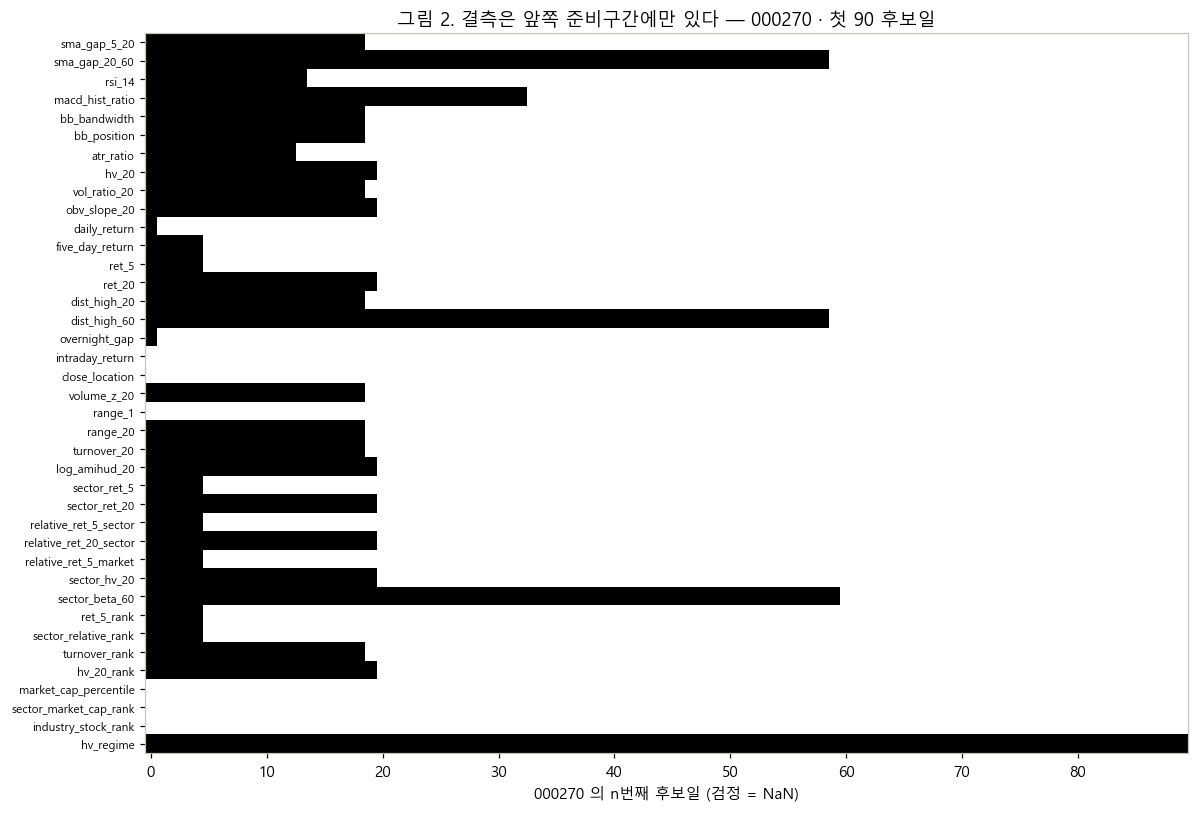

피처별 첫 유효 후보일(0부터): {'sma_gap_5_20': 19, 'sma_gap_20_60': 59, 'rsi_14': 14, 'macd_hist_ratio': 33, 'bb_bandwidth': 19, 'bb_position': 19, 'atr_ratio': 13, 'hv_20': 20, 'vol_ratio_20': 19, 'obv_slope_20': 20, 'daily_return': 1, 'five_day_return': 5, 'ret_5': 5, 'ret_20': 20, 'dist_high_20': 19, 'dist_high_60': 59, 'overnight_gap': 1, 'intraday_return': 0, 'close_location': 0, 'volume_z_20': 19, 'range_1': 0, 'range_20': 19, 'turnover_20': 19, 'log_amihud_20': 20, 'sector_ret_5': 5, 'sector_ret_20': 20, 'relative_ret_5_sector': 5, 'relative_ret_20_sector': 20, 'relative_ret_5_market': 5, 'sector_hv_20': 20, 'sector_beta_60': 60, 'ret_5_rank': 5, 'sector_relative_rank': 5, 'turnover_rank': 19, 'hv_20_rank': 20, 'market_cap_percentile': 0, 'sector_market_cap_rank': 0, 'industry_stock_rank': 0, 'hv_regime': 0}


In [5]:
# 한 종목의 앞 90 후보일 — NaN 이 어디에 있나 (행 = 피처, 열 = 그 종목의 n번째 후보일)
code0 = base.groupby("code").size().idxmax()
one = base[base.code == code0].sort_values("bas_dd").head(90)
grid = one[FEATS].isna().to_numpy().T
fig, ax = plt.subplots(figsize=(11, 7.5))
ax.imshow(grid, aspect="auto", cmap="Greys", interpolation="nearest", vmin=0, vmax=1)
ax.set_yticks(range(len(FEATS)))
ax.set_yticklabels(FEATS, fontsize=7.5)
ax.set_xlabel(f"{code0} 의 n번째 후보일 (검정 = NaN)")
ax.set_title(f"그림 2. 결측은 앞쪽 준비구간에만 있다 — {code0} · 첫 90 후보일")
ax.grid(False)
plt.tight_layout()
plt.show()
first_valid = one[FEATS].notna().to_numpy().argmax(axis=0)
print("피처별 첫 유효 후보일(0부터):", dict(zip(FEATS, first_valid.tolist(), strict=True)))

### 2.1 코드 재사용이 만든 NaN 하나 — 채울 것이 아니라 뜻이 맞는 NaN

같은 날 검증기(`scripts/verify_hf_dataset.py`)가 붉었던 원인이 **한 행**이었습니다. `036220` 은
2016-05-04 인포피아(상장폐지)의 마지막 행 뒤에 **2024-03-13 오상헬스케어**(신규상장)가 같은 코드로
다시 왔습니다. 반출은 종목의 직전 행과 비교하므로 8년 전 종가 대비 +738.57% 가 나와
`is_adj_suspect` 를 켰고, 판정기는 전년도 12월부터만 읽어 NaN 이었습니다.

이 NaN 은 "결측 처리가 필요한 값" 이 아닙니다. 품질 규약 §5 의 *"비교할 수 없는 행은 NaN, 모르는
것을 오류로 치지 않는다"* 가 맞게 적용된 결과이고, 틀린 쪽은 오히려 +738.57% 를 만든 반출입니다.

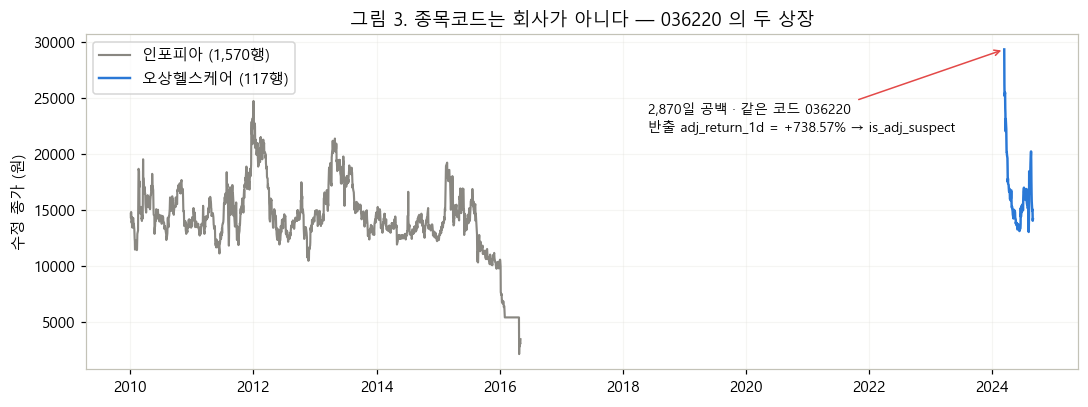

  bas_dd   name   adj_close  adj_return_1d  is_adj_suspect  is_first_listing
20240313 오상헬스케어 29,350.0000       738.5714            True             False
20240314 오상헬스케어 26,200.0000       -10.7325           False             False
이 종목은 KOSDAQ 이라 KOSPI 후보군 패널에는 없다: False


In [6]:
reuse = pq.read_table(HF, columns=["bas_dd", "code", "name", "adj_close", "adj_return_1d",
                                   "is_adj_suspect", "is_first_listing"],
                      filters=[("code", "==", "036220")]).to_pandas()
reuse["date"] = pd.to_datetime(reuse["bas_dd"])
a = reuse[reuse.name == "인포피아"]
b = reuse[reuse.name == "오상헬스케어"]
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(a["date"], a["adj_close"], color=C["gray"], lw=1.4, label=f"인포피아 ({len(a):,}행)")
ax.plot(b["date"], b["adj_close"], color=C["blue"], lw=1.6, label=f"오상헬스케어 ({len(b):,}행)")
gap = (b["date"].iloc[0] - a["date"].iloc[-1]).days
ax.annotate(f"{gap:,}일 공백 · 같은 코드 036220\n반출 adj_return_1d = "
            f"{b['adj_return_1d'].iloc[0]:+.2f}% → is_adj_suspect",
            xy=(b["date"].iloc[0], b["adj_close"].iloc[0]),
            xytext=(pd.Timestamp("2018-06-01"), b["adj_close"].max() * 0.75), fontsize=9,
            arrowprops={"arrowstyle": "->", "color": C["red"]})
ax.set_title("그림 3. 종목코드는 회사가 아니다 — 036220 의 두 상장")
ax.set_ylabel("수정 종가 (원)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()
print(b.head(2)[["bas_dd", "name", "adj_close", "adj_return_1d", "is_adj_suspect",
                 "is_first_listing"]].to_string(index=False))
print("이 종목은 KOSDAQ 이라 KOSPI 후보군 패널에는 없다:", "036220" in set(panel.code))

## 3. 분포 — 무엇이 꼬리가 긴가

winsorize 가 필요한지는 분포가 말합니다. 첨도(정규분포 0)와, **그날 안에서** |z| > 3 인 값의
비율(정규라면 0.27%)을 함께 봅니다.

In [7]:
g = panel.groupby("bas_dd", sort=False)
rows = []
for f in FEATS:
    x = panel[f].astype(float)
    z = (x - g[f].transform("mean")) / g[f].transform("std")
    rows.append({"피처": f, "왜도": x.skew(), "첨도": x.kurt(),
                 "|z|>3 %": (z.abs() > 3).mean() * 100, "최소": x.min(), "최대": x.max()})
dist = pd.DataFrame(rows).set_index("피처").sort_values("첨도", ascending=False)
display(dist.head(12).round(3))   # noqa: F821

,왜도,첨도,|z|>3 %,최소,최대
피처,,,,,
turnover_20,12.0980,244.8810,2.0980,0.0000,0.3110
vol_ratio_20,5.8810,76.6000,1.9160,0.0080,18.4080
relative_ret_20_sector,4.0180,71.9470,1.0880,-0.4920,2.7260
relative_ret_5_sector,2.3640,51.6910,1.1320,-0.3570,1.7830
ret_20,2.6030,34.2920,0.8740,-0.5690,2.7210
relative_ret_5_market,2.0040,33.5940,1.0040,-0.3560,1.7980
range_1,3.7020,32.5980,1.5800,0.0010,0.5310
overnight_gap,0.8070,31.0810,1.2760,-0.2570,0.2990
bb_bandwidth,3.3560,26.6960,1.5620,0.0130,2.1980


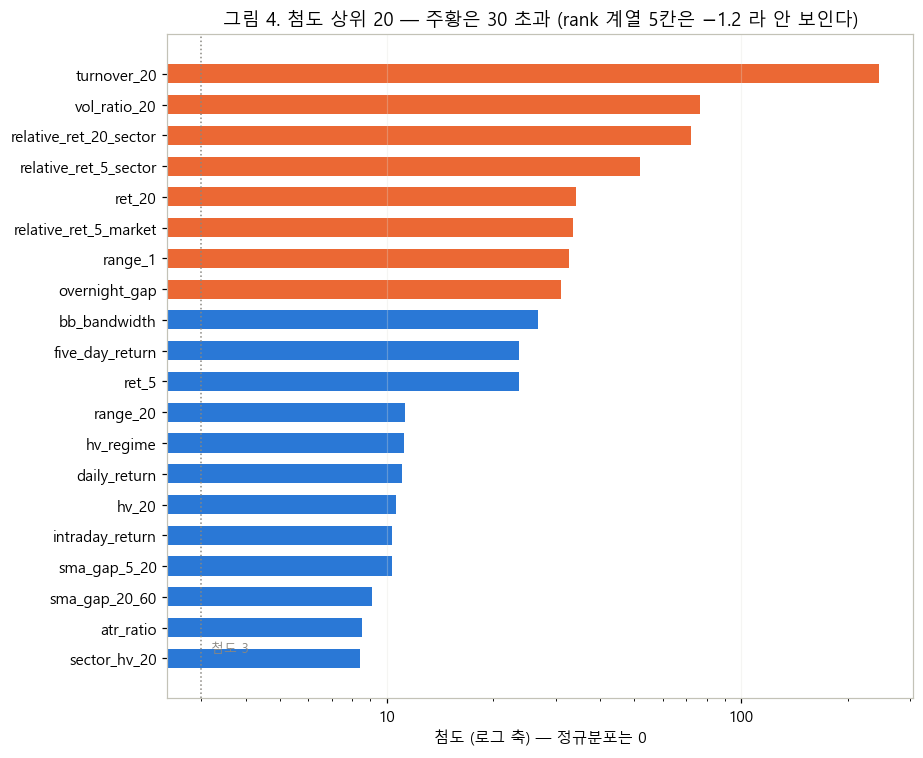

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 7))
top = dist["첨도"].head(20)
colors = [C["orange"] if v > 30 else C["blue"] for v in top.values[::-1]]
ax.barh(top.index[::-1], top.values[::-1], color=colors, height=0.62)
ax.set_xscale("log")
로그축_ASCII(ax)
ax.axvline(3, color=C["gray"], lw=1, ls=":")
ax.text(3.2, 0.2, "첨도 3", color=C["gray"], fontsize=8.5)
ax.set_xlabel("첨도 (로그 축) — 정규분포는 0")
ax.set_title("그림 4. 첨도 상위 20 — 주황은 30 초과 (rank 계열 5칸은 −1.2 라 안 보인다)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

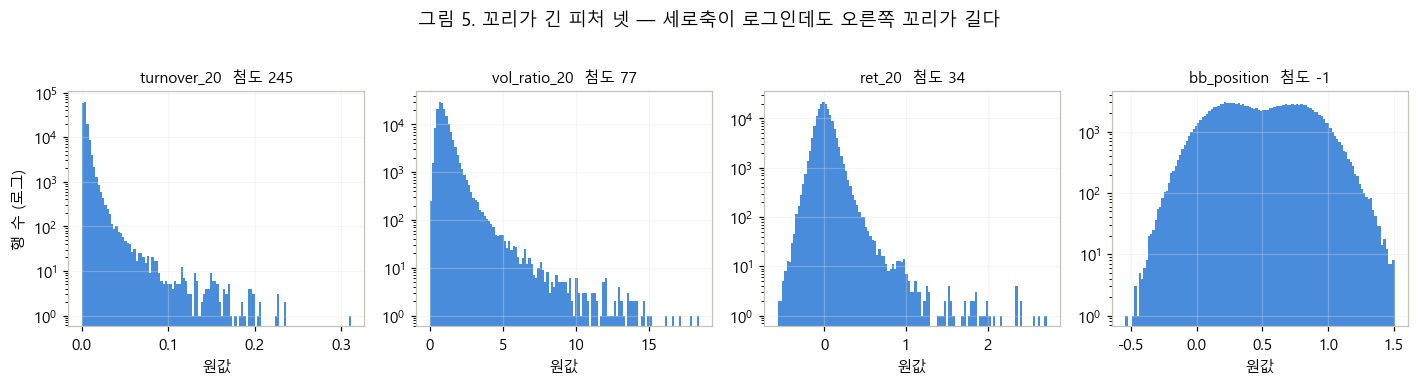

모델 표본: |bb_position| > 3 인 행 0개 · 첨도 -0.8
선택 전 패널: |bb_position| > 3 인 행 1개 · 첨도 1290.0
  bas_dd   code name  bb_position  bb_bandwidth
20130828 035420  NHN      42.0000        0.0000


In [9]:
# 꼬리가 긴 넷을 원값 그대로 — 가로축을 자르지 않고 보면 왜 winsorize 가 필요한지 보인다
four = [f for f in ("turnover_20", "vol_ratio_20", "ret_20", "bb_position") if f in FEATS]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, f in zip(axes, four, strict=True):
    x = panel[f].dropna().to_numpy()
    ax.hist(x, bins=120, color=C["blue"], alpha=0.85)
    ax.set_yscale("log")
    ax.set_title(f"{f}  첨도 {dist.loc[f, '첨도']:.0f}", fontsize=10)
    ax.set_xlabel("원값")
axes[0].set_ylabel("행 수 (로그)")
fig.suptitle("그림 5. 꼬리가 긴 피처 넷 — 세로축이 로그인데도 오른쪽 꼬리가 길다", y=1.02)
plt.tight_layout()
plt.show()
for 이름, df in (("모델 표본", panel), ("선택 전 패널", base)):
    big = df.loc[df["bb_position"].abs() > 3,
                 ["bas_dd", "code", "name", "bb_position", "bb_bandwidth"]]
    print(f"{이름}: |bb_position| > 3 인 행 {len(big)}개 · 첨도 {df['bb_position'].kurt():.1f}")
    if len(big):
        print(big.to_string(index=False))

### 3.1 🔴 첫 실측을 정정합니다 — 그 한 행은 모델 표본에 없습니다

`bb_position` 첨도가 **선택 전 패널에서는 1,290**, **모델 표본에서는 −0.8** 입니다. 차이는 한 행
(NHN 2013-08-28 · 인적분할 직전 거래정지 20일로 밴드 폭이 6e-16 · `bb_position` 42)이고, 그 행은
거래량 계열 피처 열한 개가 NaN 이라 `select_stock_feature_dataset` 이 이미 걸러 냅니다. 조합
A·C·F 가 `bb_position` 을 쓰는데, **셋 다 그 행을 안 봅니다**(각각 `vol_ratio_20`·`volume_z_20`·
`turnover_rank` 가 NaN 이라 행이 빠집니다).

이 세션 처음에 저는 선택 전 패널로 재고 *"첨도 1,290"* 이라고 이슈([#194](https://github.com/devlee328288/Alpha_Stack/issues/194))에
적었습니다. 학습에 실제로 들어가는 표본은 그게 아니었습니다 — 이슈에 정정을 달았습니다.

다만 지표 자체의 문제는 남습니다. [`features/indicators.py:231`](../../features/indicators.py#L231)
의 `width > 0` 가드를 6e-16 이 통과하는 것은 사실이고, 지금은 **다른 피처의 NaN 이 우연히 막아
주고 있을 뿐**입니다. 조합이 바뀌면(거래량 피처를 안 쓰는 조합) 들어옵니다. 신장환 님 파일이라
결정을 여쭙는 중입니다.

## 4. ① 극단값 — 분위 · 3σ · MAD 가 각각 무엇을 건드리나

세 표준이 세 방식을 씁니다.

| 방식 | 출처 | 경계 |
|---|---|---|
| 분위 | 국내 재무 논문 관행 "상하위 1% 윈저화" · MSCI 품질지수(5/95 · 200종 예시) | 그날 1%/99% 분위 |
| 3σ | Barra USE4 (MSCI 2011) | 평균 ± 3 × 표준편차 |
| MAD | qlib `RobustZScoreNorm` · 중국 A주 관행 | 중앙값 ± 3 × 1.4826 × MAD |

셋 다 "3" 이나 "1%" 같은 숫자를 갖고 있지만 **무엇에 대한 숫자인지**가 다릅니다. 분위는 **종목 수에
대한 비율**입니다. 우리 횡단면은 49개라 1% 는 **0.49종**입니다.

In [10]:
n = n_by_date
print(f"날짜별 종목 수 × 1% = {n.median() * 0.01:.2f}종 (중앙값 기준)")
print(f"→ pandas 분위(선형보간)는 최솟값과 두 번째 값 사이 {0.01 * (n.median() - 1):.2f} "
      "지점을 경계로 잡는다:")
print("   양끝 한 값씩만 닿고, 그 값도 두 번째 값 근처로 옮겨질 뿐이다.")

W = {
    "분위 1/99": P.winsorize_cross_section(panel, FEATS, method="quantile", limits=(0.01, 0.99)),
    "3σ": P.winsorize_cross_section(panel, FEATS, method="sigma", k=3.0),
    "MAD 3": P.winsorize_cross_section(panel, FEATS, method="mad", k=3.0),
}
sd = g[FEATS].transform("std")
raw = panel[FEATS].astype(float)
rows = []
for name, w in W.items():
    touched = (w != raw) & raw.notna()
    move = ((raw - w).abs() / sd).where(touched)
    rows.append(pd.DataFrame({
        "방식": name,
        "피처": FEATS,
        "건드린 비율 %": touched.mean().to_numpy() * 100,
        "이동/σ 중앙": move.median().to_numpy(),
        "이동/σ 최대": move.max().to_numpy(),
    }))
eff = pd.concat(rows, ignore_index=True)
piv = eff.pivot(index="피처", columns="방식", values="건드린 비율 %").loc[FEATS]
display(piv.loc[dist.index[:12]].round(2))   # noqa: F821

날짜별 종목 수 × 1% = 0.49종 (중앙값 기준)
→ pandas 분위(선형보간)는 최솟값과 두 번째 값 사이 0.48 지점을 경계로 잡는다:
   양끝 한 값씩만 닿고, 그 값도 두 번째 값 근처로 옮겨질 뿐이다.


방식,3σ,MAD 3,분위 1/99
피처,,,
turnover_20,2.1000,6.8400,4.1800
vol_ratio_20,1.9200,5.5900,4.1800
relative_ret_20_sector,1.0900,3.5500,4.1800
relative_ret_5_sector,1.1300,3.7300,4.1800
ret_20,0.8700,2.6500,4.1800
relative_ret_5_market,1.0000,3.1100,4.1800
range_1,1.5800,4.4400,4.1800
overnight_gap,1.2800,3.6200,4.1700
bb_bandwidth,1.5600,4.4600,4.1800


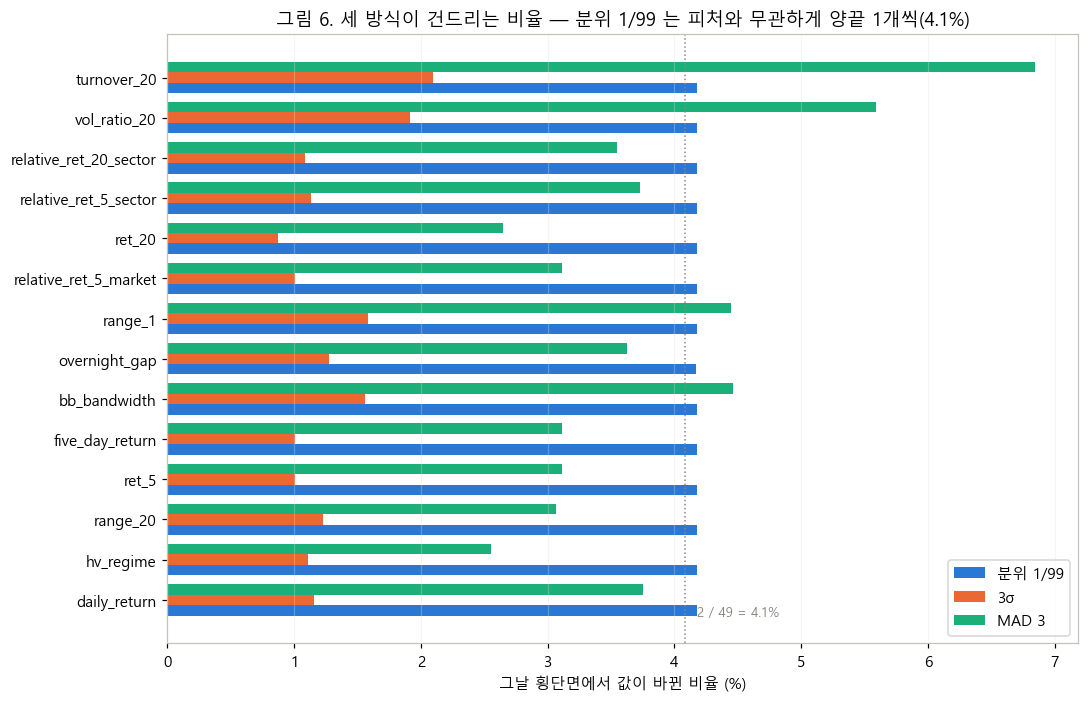

In [11]:
show = [f for f in dist.index if f in piv.index and not f.endswith("_rank")][:14]
fig, ax = plt.subplots(figsize=(10, 6.5))
y = np.arange(len(show))
h = 0.26
for i, (name, col) in enumerate(zip(["분위 1/99", "3σ", "MAD 3"],
                                     [C["blue"], C["orange"], C["aqua"]], strict=True)):
    ax.barh(y + (1 - i) * h, piv.loc[show, name].to_numpy(), height=h, color=col, label=name)
ax.set_yticks(y)
ax.set_yticklabels(show)
ax.invert_yaxis()
ax.axvline(100 * 2 / n.median(), color=C["gray"], lw=1, ls=":")
ax.text(100 * 2 / n.median() + 0.1, len(show) - 0.6, "2 / 49 = 4.1%", color=C["gray"], fontsize=8.5)
ax.set_xlabel("그날 횡단면에서 값이 바뀐 비율 (%)")
ax.set_title("그림 6. 세 방식이 건드리는 비율 — 분위 1/99 는 피처와 무관하게 양끝 1개씩(4.1%)")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

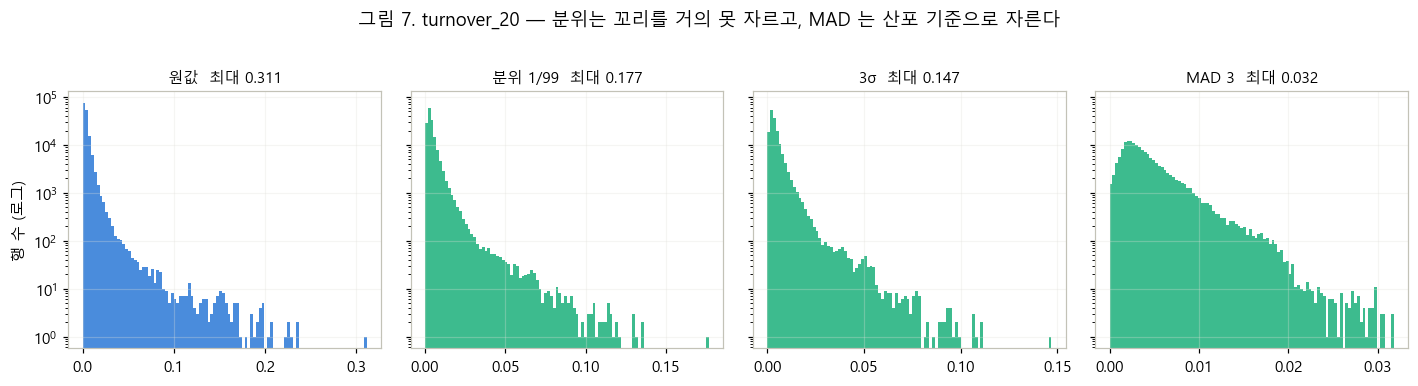

In [12]:
# 같은 피처를 세 방식으로 당긴 뒤 — turnover_20 (첨도 가장 큰 연속 피처 중 하나)
f = "turnover_20"
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
series = [("원값", raw[f]), *[(k, W[k][f]) for k in W]]
for ax, (name, s) in zip(axes, series, strict=True):
    ax.hist(s.dropna(), bins=100, color=C["blue"] if name == "원값" else C["aqua"], alpha=0.85)
    ax.set_yscale("log")
    ax.set_title(f"{name}  최대 {s.max():.3f}", fontsize=10)
axes[0].set_ylabel("행 수 (로그)")
fig.suptitle(f"그림 7. {f} — 분위는 꼬리를 거의 못 자르고, MAD 는 산포 기준으로 자른다", y=1.02)
plt.tight_layout()
plt.show()

**결정 — 기본은 MAD 3배.** 셋을 실제로 걸어 보면 차이가 분명합니다.

- **분위 1/99 는 피처와 무관하게 4.18%** 를 건드립니다. 꼬리가 아무리 길어도, 아무리 짧아도
  같은 값입니다 — 양끝 한 개씩이라는 **개수**를 정한 것이지 극단값을 정한 게 아니기 때문입니다.
- **3σ 는 꼬리가 길수록 덜 잡습니다.** `turnover_20`(첨도 245)에서 2.10% 인데 `ret_20`(첨도 34)에서
  0.87% 입니다. 평균과 표준편차가 극단값 자체에 끌려 경계가 밖으로 밀립니다.
- **MAD 3배만 꼬리 길이를 따라갑니다.** `turnover_20` 6.84% · `ret_20` 2.65% — 첨도 순서와 같습니다.

중앙값·MAD 는 극단값에 안 끌리고, qlib `RobustZScoreNorm` 이 같은 정의(`1.4826`)를 씁니다. 분위
방식은 국내 학술 관행과 비교하려고 옵션으로 남깁니다. `is_extreme_return` 원칙(진짜 사건은 **행을
남긴다**)과는 충돌하지 않습니다 — winsorize 는 값을 당길 뿐 행을 지우지 않고, 라벨·수익률·가격·
플래그 칸은 `PROTECTED_PREFIXES` 가 받지도 않습니다.

## 5. ② z-score — 날짜 안 vs 전 구간, 어디서 새는가

수업 07단원 3장의 `StandardScaler` 는 **표본 전체**의 평균·표준편차를 씁니다. 그걸 시계열 패널에
그대로 걸면 2024년의 평균이 2012년 행의 값을 바꿉니다 — `features/__init__.py` 경고 2 가 그것이고,
`models/logistic.py` 가 `StandardScaler` 를 Pipeline **안**에 두어 폴드마다 학습 구간만 보게 한
이유입니다. 횡단면 z-score 는 방향이 다릅니다: **그날 종목들끼리**의 평균·표준편차라 미래를 볼 수
없습니다. 그래서 학습·검증을 가르기 전에 걸어도 됩니다.

그 차이가 실제로 얼마나 큰지 — 그날 평균·표준편차가 시간에 따라 얼마나 움직이는지 봅니다.

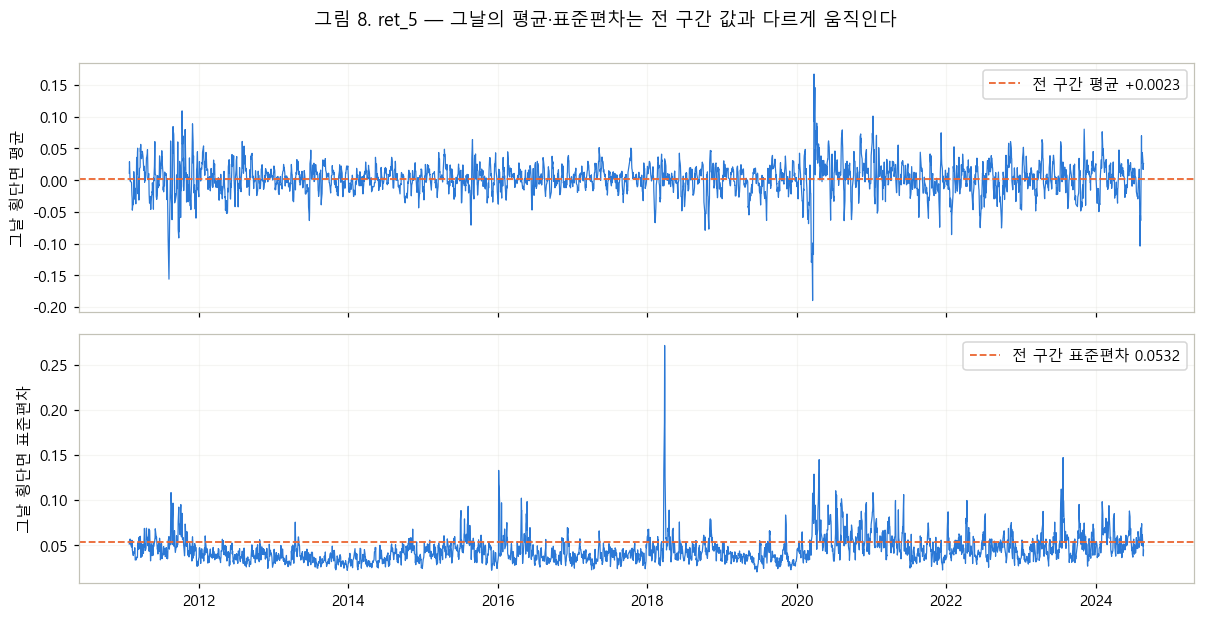

그날 표준편차 최대/최소 = 13.5배 · 전 구간 값이 그날 값과 2배 넘게 다른 날: 3.1%


In [13]:
f = "ret_5"
daily = panel.groupby("bas_dd")[f].agg(["mean", "std"])
daily.index = pd.to_datetime(daily.index)
glob_mean, glob_std = panel[f].mean(), panel[f].std()
fig, axes = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True)
axes[0].plot(daily.index, daily["mean"], color=C["blue"], lw=0.8)
axes[0].axhline(glob_mean, color=C["orange"], lw=1.2, ls="--",
                label=f"전 구간 평균 {glob_mean:+.4f}")
axes[0].set_ylabel("그날 횡단면 평균")
axes[0].legend(loc="upper right")
axes[1].plot(daily.index, daily["std"], color=C["blue"], lw=0.8)
axes[1].axhline(glob_std, color=C["orange"], lw=1.2, ls="--",
                label=f"전 구간 표준편차 {glob_std:.4f}")
axes[1].set_ylabel("그날 횡단면 표준편차")
axes[1].legend(loc="upper right")
fig.suptitle(f"그림 8. {f} — 그날의 평균·표준편차는 전 구간 값과 다르게 움직인다", y=1.0)
plt.tight_layout()
plt.show()
ratio = daily["std"].max() / daily["std"].min()
print(f"그날 표준편차 최대/최소 = {ratio:.1f}배 · 전 구간 값이 그날 값과 2배 넘게 다른 날: "
      f"{((daily['std'] / glob_std > 2) | (daily['std'] / glob_std < 0.5)).mean():.1%}")

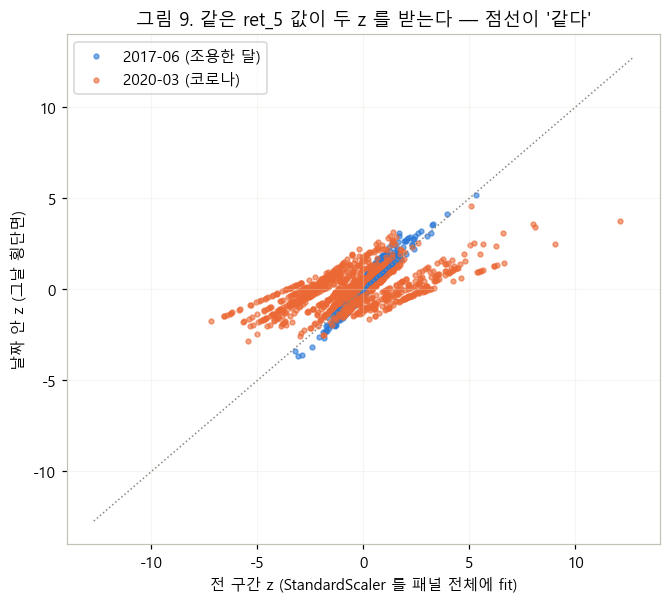

2020-03 행의 |전 구간 z| 중앙: 1.44 · |날짜 안 z| 중앙: 0.61


In [14]:
# 같은 행이 두 방식으로 얼마나 다른 z 를 받는가 — 2020-03 (코로나) 와 2017-06 (조용한 달)
zc = P.zscore_cross_section(panel, [f])[f]
zg = (panel[f] - glob_mean) / glob_std
sample = panel["bas_dd"].str.startswith(("202003", "201706"))
fig, ax = plt.subplots(figsize=(6.2, 5.6))
m1 = sample & panel["bas_dd"].str.startswith("202003")
m2 = sample & panel["bas_dd"].str.startswith("201706")
ax.scatter(zg[m2], zc[m2], s=10, color=C["blue"], alpha=0.6, label="2017-06 (조용한 달)")
ax.scatter(zg[m1], zc[m1], s=10, color=C["orange"], alpha=0.6, label="2020-03 (코로나)")
lim = max(abs(zg[sample]).max(), abs(zc[sample]).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], color=C["gray"], lw=1, ls=":")
ax.set_xlabel("전 구간 z (StandardScaler 를 패널 전체에 fit)")
ax.set_ylabel("날짜 안 z (그날 횡단면)")
ax.set_title(f"그림 9. 같은 {f} 값이 두 z 를 받는다 — 점선이 '같다'")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()
print("2020-03 행의 |전 구간 z| 중앙:", f"{zg[m1].abs().median():.2f}",
      "· |날짜 안 z| 중앙:", f"{zc[m1].abs().median():.2f}")

코로나 달의 수익률은 전 구간 기준으로는 전부 "극단" 이지만 그날 안에서는 평범한 값입니다.
**"그날 종목들 중 어디쯤인가"** 를 묻는 것이 횡단면 z-score 이고, 이것은 검증 구간의 평균·분산을
빌리지 않습니다. 시계열 방향 스케일링은 그대로 Pipeline 이 맡습니다 — 두 방향을 섞지 않습니다.

## 6. ③ 중립화 — 업종·시총이 피처를 얼마나 설명하고, IC 는 어떻게 바뀌나

Kakushadze(2016)의 `indneutralize` 는 업종 안 평균 빼기, 중국 A주 관행은 **업종 더미 + log 시총**
회귀 잔차입니다. 우리 후보군은 업종 10개 × 종목 5개라 업종 평균을 빼면 자유도 50 → 40 입니다.
잡음만 있어도 업종 R² 가 9/49 ≈ 0.18 이 나오므로, 그 위로 얼마나 더 설명하는지를 봐야 합니다.

In [15]:
logcap = np.log(panel["market_cap"].astype(float).clip(lower=1))
panel["log_cap"] = logcap
cap_rank = logcap.groupby(panel["bas_dd"]).rank()
rows = []
for f in FEATS:
    x = panel[f].astype(float)
    ok = x.notna()
    xd, dd, ss = x[ok], panel["bas_dd"][ok], panel["industry"][ok]
    tot = xd.groupby(dd).var()
    resid = xd - xd.groupby([dd, ss]).transform("mean")
    r2 = (1 - resid.groupby(dd).var() / tot).replace([np.inf, -np.inf], np.nan)
    xr, cr = xd.groupby(dd).rank(), cap_rank[ok]
    mx, mc = xr.groupby(dd).transform("mean"), cr.groupby(dd).transform("mean")
    num = ((xr - mx) * (cr - mc)).groupby(dd).sum()
    den = np.sqrt(((xr - mx) ** 2).groupby(dd).sum() * ((cr - mc) ** 2).groupby(dd).sum())
    rows.append({"피처": f, "업종 R² 중앙": r2.median(),
                 "log시총 순위상관 중앙": (num / den).median()})
axes_tbl = pd.DataFrame(rows).set_index("피처")
display(axes_tbl.sort_values("업종 R² 중앙", ascending=False).round(3))   # noqa: F821

,업종 R² 중앙,log시총 순위상관 중앙
피처,,
sector_ret_5,1.0000,0.0130
sector_ret_20,1.0000,0.0220
sector_market_cap_rank,1.0000,-0.5880
sector_hv_20,1.0000,0.0000
log_amihud_20,0.4760,-0.8750
market_cap_percentile,0.4330,1.0000
rsi_14,0.3270,0.0420
ret_5_rank,0.3250,0.0230
bb_position,0.3200,0.0300


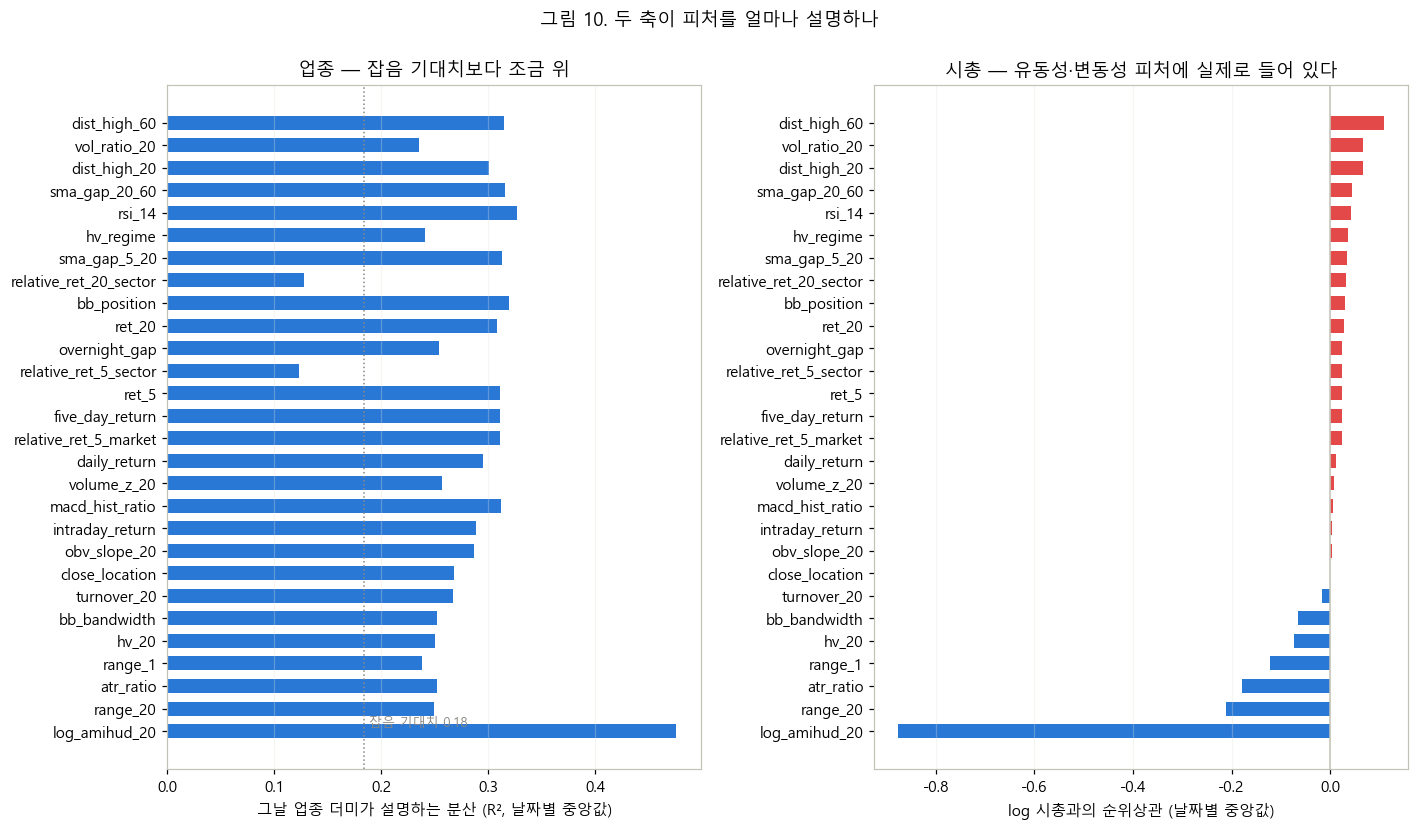

In [16]:
show = [f for f in FEATS if not f.startswith("sector_") and not f.endswith("_rank")
        and f not in ("market_cap_percentile", "industry_stock_rank")]
tbl = axes_tbl.loc[show].sort_values("log시총 순위상관 중앙")
fig, axes = plt.subplots(1, 2, figsize=(13, 7.5))
ax = axes[0]
v = tbl["업종 R² 중앙"]
ax.barh(v.index, v.values, color=C["blue"], height=0.62)
ax.axvline(9 / 49, color=C["gray"], lw=1, ls=":")
ax.text(9 / 49 + 0.005, 0.2, "잡음 기대치 0.18", color=C["gray"], fontsize=8.5)
ax.set_xlabel("그날 업종 더미가 설명하는 분산 (R², 날짜별 중앙값)")
ax.set_title("업종 — 잡음 기대치보다 조금 위")
ax.grid(axis="y", visible=False)
ax = axes[1]
v = tbl["log시총 순위상관 중앙"]
ax.barh(v.index, v.values, color=[C["red"] if x > 0 else C["blue"] for x in v.values], height=0.62)
ax.axvline(0, color=C["light"], lw=1)
ax.set_xlabel("log 시총과의 순위상관 (날짜별 중앙값)")
ax.set_title("시총 — 유동성·변동성 피처에 실제로 들어 있다")
ax.grid(axis="y", visible=False)
fig.suptitle("그림 10. 두 축이 피처를 얼마나 설명하나", y=1.0)
plt.tight_layout()
plt.show()

### 6.1 IC 로 판정한다 — 중립화 전후

축이 피처를 설명한다고 해서 빼는 것이 맞다는 뜻은 아닙니다. 팩터가 검증되는 표준 방법은 **IC**
(그날 피처 순위와 5일 실현수익률 순위의 상관 · 날짜별 평균)입니다. 다섯 파이프라인으로 같은
피처를 만들어 IC 평균과 ICIR(평균/표준편차)을 비교합니다. 라벨이 아니라 `fwd_return_5d`
(T+1 시가 → T+6 시가)를 씁니다.

In [17]:
def ic_table(feats_frame: pd.DataFrame, target: pd.Series, dates: pd.Series) -> pd.DataFrame:
    """날짜별 스피어만 IC 의 평균·ICIR. 벡터화(apply 없음)."""
    tr = target.groupby(dates).rank()
    mt = tr.groupby(dates).transform("mean")
    out = {}
    for f in feats_frame.columns:
        x = feats_frame[f].astype(float)
        ok = x.notna() & target.notna()
        xr = x[ok].groupby(dates[ok]).rank()
        mx = xr.groupby(dates[ok]).transform("mean")
        t_ok, mt_ok = tr[ok], mt[ok]
        num = ((xr - mx) * (t_ok - mt_ok)).groupby(dates[ok]).sum()
        den = np.sqrt(((xr - mx) ** 2).groupby(dates[ok]).sum()
                      * ((t_ok - mt_ok) ** 2).groupby(dates[ok]).sum())
        ic = (num / den).replace([np.inf, -np.inf], np.nan).dropna()
        out[f] = {"IC 평균": ic.mean(), "ICIR": ic.mean() / ic.std(), "날짜 수": len(ic)}
    return pd.DataFrame(out).T


CORE = [f for f in show if f in FEATS]
variants = {
    "원값": panel[CORE].astype(float),
    "winsor+z": P.preprocess_cross_section(panel, CORE),
    "+업종": P.preprocess_cross_section(panel, CORE, neutralize={"groups": "industry"}),
    "+시총": P.preprocess_cross_section(
        panel, CORE, neutralize={"groups": None, "controls": ("log_cap",)}),
    "+업종+시총": P.preprocess_cross_section(
        panel, CORE, neutralize={"groups": "industry", "controls": ("log_cap",)}),
}
ics = {k: ic_table(v, panel["fwd_return_5d"], panel["bas_dd"]) for k, v in variants.items()}
summary = pd.DataFrame({k: v["IC 평균"] for k, v in ics.items()})
icir = pd.DataFrame({k: v["ICIR"] for k, v in ics.items()})
print("피처별 |IC 평균| 의 평균 · ICIR 절댓값 평균")
ic_overall = pd.DataFrame({"|IC| 평균": summary.abs().mean(), "|ICIR| 평균": icir.abs().mean()})
display(ic_overall.round(4))   # noqa: F821

피처별 |IC 평균| 의 평균 · ICIR 절댓값 평균


,|IC| 평균,|ICIR| 평균
원값,0.0211,0.1050
winsor+z,0.0211,0.1050
+업종,0.0191,0.1144
+시총,0.0211,0.1063
+업종+시총,0.0180,0.1085


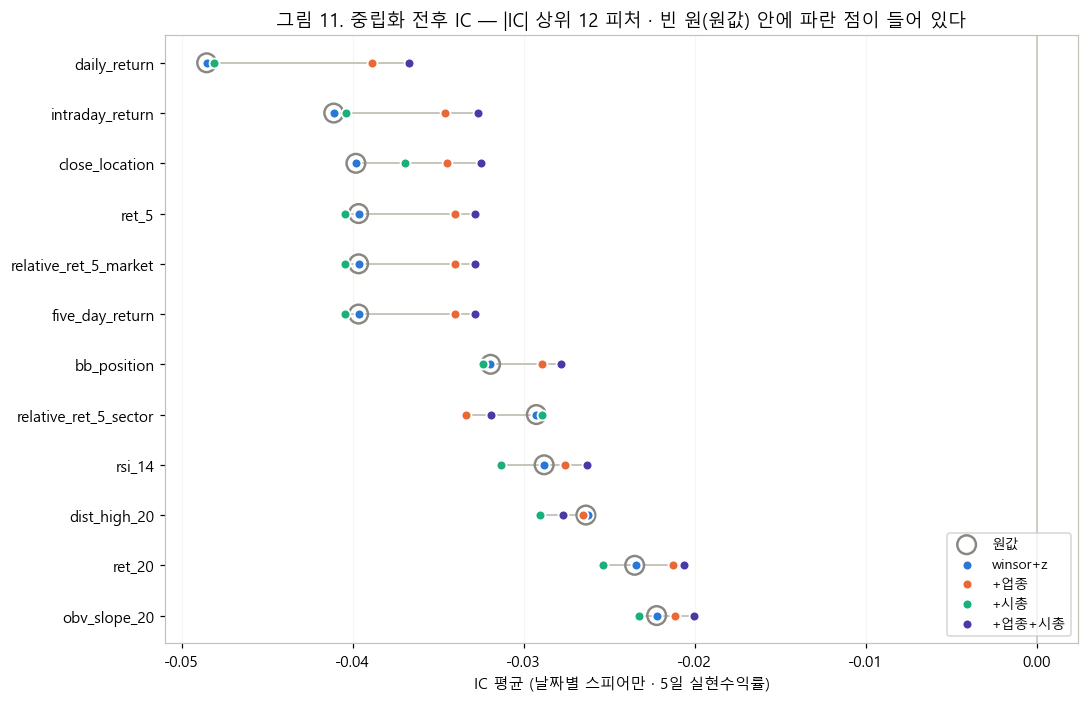

,원값,winsor+z,+업종,+시총,+업종+시총
daily_return,-0.0485,-0.0485,-0.0389,-0.0481,-0.0367
intraday_return,-0.0411,-0.0411,-0.0346,-0.0404,-0.0327
close_location,-0.0398,-0.0398,-0.0345,-0.0369,-0.0325
ret_5,-0.0396,-0.0396,-0.0340,-0.0405,-0.0329
relative_ret_5_market,-0.0396,-0.0396,-0.0340,-0.0405,-0.0329
five_day_return,-0.0396,-0.0396,-0.0340,-0.0405,-0.0329
bb_position,-0.0319,-0.0319,-0.0289,-0.0323,-0.0278
relative_ret_5_sector,-0.0293,-0.0292,-0.0334,-0.0289,-0.0319
rsi_14,-0.0288,-0.0288,-0.0276,-0.0313,-0.0263
dist_high_20,-0.0264,-0.0262,-0.0265,-0.0290,-0.0277


In [18]:
top_feats = summary["원값"].abs().sort_values(ascending=False).head(12).index
fig, ax = plt.subplots(figsize=(10, 6.5))
y = np.arange(len(top_feats))
for yi in y:
    ax.plot([summary.loc[top_feats[yi]].min(), summary.loc[top_feats[yi]].max()], [yi, yi],
            color=C["light"], lw=1.2, zorder=2)
# 원값은 큰 테두리 원으로 뒤에 둔다 — winsor+z 가 그 위에 정확히 겹치기 때문이다(아래 설명).
ax.scatter(summary.loc[top_feats, "원값"], y, s=150, facecolor="none",
           edgecolor=C["gray"], linewidth=1.6, label="원값", zorder=3)
for k, col in zip(["winsor+z", "+업종", "+시총", "+업종+시총"],
                  [C["blue"], C["orange"], C["aqua"], C["violet"]], strict=True):
    ax.scatter(summary.loc[top_feats, k], y, s=42, color=col, label=k, zorder=4,
               edgecolor="white", linewidth=1.2)
ax.axvline(0, color=C["light"], lw=1)
ax.set_yticks(y)
ax.set_yticklabels(top_feats)
ax.invert_yaxis()
ax.set_xlabel("IC 평균 (날짜별 스피어만 · 5일 실현수익률)")
ax.set_title("그림 11. 중립화 전후 IC — |IC| 상위 12 피처 · 빈 원(원값) 안에 파란 점이 들어 있다")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()
display(summary.loc[top_feats].round(4))   # noqa: F821

### 6.2 읽는 법 — 세 가지가 한 그림에 있습니다

**① `winsor+z` 가 원값 위에 정확히 겹칩니다** (빈 회색 원 안의 파란 점). 우연이 아니라 정의입니다 —
IC 는 **순위**상관이고 winsorize·z-score 는 그날 안에서 순서를 보존하는 변환이라, 순위가 (동률이
새로 생기는 몇 행 말고는) 그대로입니다. 그러니 **IC 로는 winsorize 의 효과를 잴 수 없습니다.**
①②의 값어치는 다른 데서 옵니다 — 로지스틱처럼 값의 크기를 쓰는 모델, 그리고 극단값 한 행이
회귀 계수를 끄는 것을 막는 데서.

**② 중립화는 IC 를 줄이고 ICIR 을 늘립니다.** 위 표에서 `|IC| 평균` 은 원값 0.0211 → +업종 0.0191
로 **9.5% 줄고**, `|ICIR| 평균` 은 0.1050 → 0.1144 로 **8.9% 늡니다.** 방향이 반대입니다. 업종
공통 성분을 빼면 신호의 크기는 작아지지만 날짜마다 덜 흔들린다는 뜻입니다.

**③ 그래서 축을 먼저 정해야 합니다.** 우리 목적은 그날 후보 안에서 살 종목을 **줄 세우는 것**
(long-only Top-K)이고, 랭킹에서는 **한 번 크게 맞히는 것보다 매일 조금씩 맞히는 것**이 낫습니다.
그 기준이 ICIR 이라 **기본 축은 업종**으로 정합니다. 시총까지 더하면 ICIR 이 0.1085 로 도로
내려가므로(업종만보다 낮음) 기본에서 뺍니다 — `log_amihud_20`·`range_20` 처럼 시총과 상관이 큰
피처를 쓸 때만 `controls=("log_cap",)` 을 켭니다.

> 🔴 이것은 **선정 축이 순위를 지배한** 또 한 사례입니다. |IC| 로 고르면 "중립화하지 말라",
> ICIR 로 고르면 "업종 중립화하라" 입니다. 어느 쪽을 쓰는지 적지 않으면 다음 사람이 다른 답을
> 얻습니다.

## 7. ④ 순위 — uniform · gaussian · signed

| 방식 | 출처 | 값 |
|---|---|---|
| uniform | Kakushadze `rank(x)` · 우리 `*_rank` 5칸 | (순위 − 0.5) / n ∈ (0, 1) |
| gaussian | qlib `CSRankNorm` 의 목적("정규처럼") | Φ⁻¹(uniform) ≈ N(0, 1) |
| signed | Gu·Kelly·Xiu (RFS 2020) | 2 × 순위 / (n + 1) − 1 ∈ (−1, 1) |

셋은 서로 단조 변환이라 트리에는 같고, 로지스틱에는 gaussian 이 정규 가정과 맞습니다. 결측은
순위에서 빠지고 결측으로 남깁니다(GKX 는 0 으로 채우지만 채울지는 모델이 정합니다).

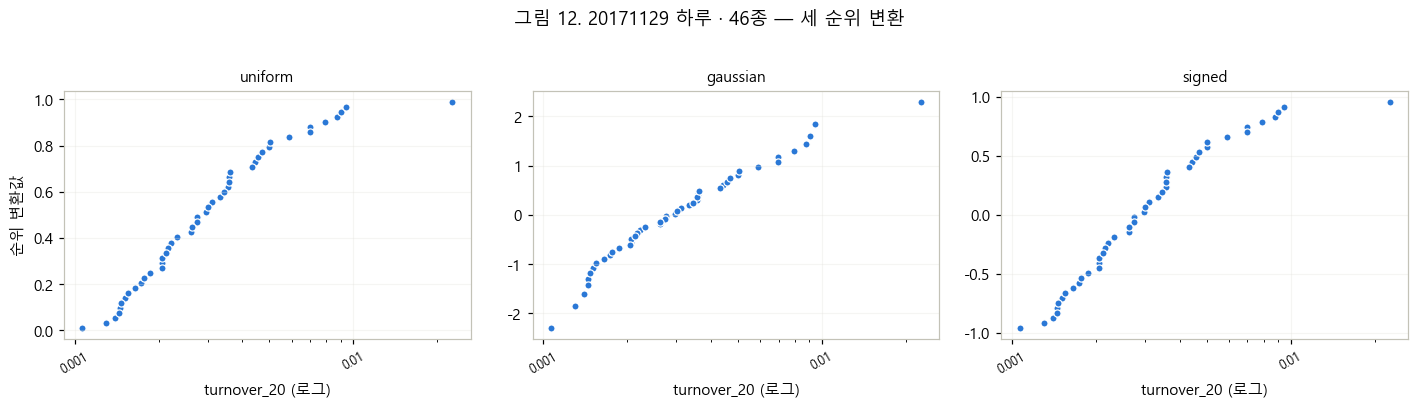

In [19]:
f = "turnover_20"
one_day = panel[panel.bas_dd == panel.bas_dd.iloc[len(panel) // 2]]
R = {m: P.rank_cross_section(one_day, [f], method=m)[f] for m in ("uniform", "gaussian", "signed")}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (m, r) in zip(axes, R.items(), strict=True):
    ax.scatter(one_day[f], r, s=22, color=C["blue"], edgecolor="white", linewidth=0.8)
    ax.set_xscale("log")
    로그축_ASCII(ax)
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
    ax.set_title(f"{m}", fontsize=10)
    ax.set_xlabel(f"{f} (로그)")
axes[0].set_ylabel("순위 변환값")
fig.suptitle(f"그림 12. {one_day.bas_dd.iloc[0]} 하루 · {len(one_day)}종 — 세 순위 변환", y=1.02)
plt.tight_layout()
plt.show()

## 8. 트리 모델에 무엇이 유효한가 — 실증

결정나무는 "x ≤ 임계값" 으로 나누므로 **전 표본에 같은 단조 변환**(로그·전체 스케일링)을 걸어도
같은 분할을 찾습니다 — LightGBM·RandomForest 에 `StandardScaler` 가 필요 없는 이유입니다. 그런데
**횡단면 변환은 그것이 아닙니다.** 그날 기준으로 바꾸면 "절대 수준" 이 "그날 안 상대 위치" 로 뜻이
바뀌고 날짜가 다른 두 행의 순서가 뒤집힙니다. 둘 다 같은 모델·같은 분할로 확인합니다.
RandomForest(수업 07단원 19·20번)는 시드를 고정하면 결정적이라 "같다/다르다" 를 셀 수 있습니다.

In [20]:
G = [f for f in ("dist_high_60", "sma_gap_20_60", "relative_ret_5_market", "rsi_14", "hv_20",
                 "turnover_20") if f in FEATS]                       # 조합 G (#155)
sub = panel.dropna(subset=G + ["label_numeric"]).copy()
train = sub["bas_dd"] < "20200101"
test = ~train
y_tr, y_te = sub.loc[train, "label_numeric"], sub.loc[test, "label_numeric"]


def fit_predict(X: pd.DataFrame) -> np.ndarray:
    rf = RandomForestClassifier(n_estimators=150, max_depth=6, random_state=0, n_jobs=-1)
    rf.fit(X.loc[train].to_numpy(), y_tr)
    return rf.predict(X.loc[test].to_numpy())


base = fit_predict(sub[G].astype(float))
X_log = sub[G].astype(float).apply(lambda s: np.sign(s) * np.log1p(s.abs()))   # 전 표본 단조
X_scaled = (sub[G].astype(float) - sub[G].astype(float).mean()) / sub[G].astype(float).std()
X_rank = P.rank_cross_section(sub, G)                                             # 날짜 안
X_neu = P.preprocess_cross_section(
    sub, G, neutralize={"groups": "industry", "controls": ("log_cap",)})
rows = []
for name, X in [("원값", sub[G].astype(float)), ("전 표본 로그", X_log), ("전 표본 z", X_scaled),
                ("날짜 안 gaussian rank", X_rank), ("날짜 안 winsor+z+중립화", X_neu)]:
    ok = X.notna().all(axis=1)
    pred = fit_predict(X.fillna(X.median()))
    rows.append({"입력": name, "정확도": (pred == y_te).mean(),
                 "상승 precision": (((pred == 1) & (y_te == 1)).sum()
                                  / max((pred == 1).sum(), 1)),
                 "원값과 다른 예측 수": int((pred != base).sum()),
                 "결측 채운 행": int((~ok).sum())})
tree_tbl = pd.DataFrame(rows).set_index("입력")
tree_tbl["다른 예측 %"] = tree_tbl["원값과 다른 예측 수"] / int(test.sum()) * 100
display(tree_tbl.round(4))   # noqa: F821
print(f"검증 {test.sum():,}행 (2020-01 ~) · 학습 {train.sum():,}행 · 조합 G {len(G)}개")

,정확도,상승 precision,원값과 다른 예측 수,결측 채운 행,다른 예측 %
입력,,,,,
원값,0.3938,0.4042,0,0,0.0000
전 표본 로그,0.3939,0.4043,9,0,0.0161
전 표본 z,0.3932,0.4026,331,0,0.5918
날짜 안 gaussian rank,0.3806,0.3418,15312,0,27.3746
날짜 안 winsor+z+중립화,0.3731,0.3531,18502,0,33.0777


검증 55,935행 (2020-01 ~) · 학습 104,001행 · 조합 G 6개


### 8.1 읽는 법 — 그리고 🔴 예상과 다른 결과 하나

**전 표본 단조 변환은 사실상 아무것도 안 합니다.** 로그는 55,935개 예측 중 **9개**(0.02%), 전
표본 z 는 **331개**(0.59%)만 바뀝니다. 이론상 0 이어야 하는데 0 이 아닌 이유는 부동소수입니다 —
변환 뒤 값이 미세하게 뭉치면 후보 분할점이 달라지고, RandomForest 의 특성 서브샘플링이 그
차이를 증폭합니다. 정확도는 소수 넷째 자리까지 같습니다(0.3938 vs 0.3939 vs 0.3932). **트리에
`StandardScaler` 가 필요 없다는 통념은 여기서 확인됩니다.**

**횡단면 변환은 27~33% 의 예측을 바꿉니다.** 뜻이 실제로 달라졌다는 증거입니다.

🔴 **그런데 이 실험에서는 성능이 낮아졌습니다.** 정확도 0.3938 → 0.3806(순위) · 0.3731(중립화),
상승 precision 0.4042 → 0.3418 · 0.3531. 전처리를 만들어 놓고 이렇게 적는 것이 이상해 보이지만,
숫자를 고쳐 적는 것보다 낫습니다. 왜 그런지 짚어 둡니다.

- **라벨이 절대 기준입니다.** 우리 라벨은 T+1→T+6 수익률의 **±2% 절대 밴드**입니다
  ([ADR 0006](../../docs/decisions/0006-개별종목-중립대와-평가기준선.md)). 피처를 "그날 안에서
  몇 등인가" 로 바꾸면, 전부 오른 날의 1등과 전부 내린 날의 1등이 같은 값을 받습니다 — 절대
  임계로 그은 라벨과 축이 어긋납니다. 라벨을 **횡단면 순위**로 바꾸면(예: 그날 상위 20%) 방향이
  맞습니다.
- **이 실험은 단일 분할·조합 G·RF 하나입니다.** 워크포워드 폴드별로 다시 재야 결론이 됩니다.
- **6.1 의 ICIR 과 어긋나지 않습니다.** ICIR 은 "IC 가 날마다 얼마나 안 흔들리나" 이고 여기 표는
  "3분류 정확도" 입니다. 두 축이 다른 것을 재고 있습니다.

**그래서 기본값을 어떻게 두었나** — `preprocess_cross_section` 의 기본은 winsorize + z-score 이고
**중립화·순위는 꺼져 있습니다**(인자를 줘야 켜집니다). 값의 크기를 쓰는 모델(로지스틱)과 극단값
방어에는 ①② 가 바로 도움이 되고, ③④ 는 **라벨 축을 바꾸는 실험과 함께** 켜야 하기 때문입니다.

## 9. 정리

| 단계 | 결정 | 근거 (이 노트북에서 잰 것) |
|---|---|---|
| ① winsorize | **MAD 3배 · 1.4826** 기본 · 분위/3σ 는 옵션 | 분위는 꼬리 길이와 무관하게 늘 4.18%(횡단면 49 → 1% = 0.49종) · 3σ 는 꼬리가 길수록 덜 잡는다 · MAD 만 첨도 순서를 따라간다 (4절) |
| ② z-score | **날짜 안** · ddof=1 · 시계열 방향은 Pipeline 유지 | 그날 σ 가 최대/최소 **13.5배** · 전 구간 값과 2배 넘게 다른 날이 3.1% · 코로나 달 |z| 중앙 1.44 → 0.61 (5절) |
| ③ 중립화 | **업종 기본 · 시총은 필요할 때만** · 다만 아래 ⚠️ | ICIR 0.1050 → **0.1144**(업종) · 시총까지 더하면 0.1085 로 도로 내려간다 (6.1) |
| ④ rank | gaussian 기본 · uniform·signed 옵션 | 셋이 서로 단조 (7절) |
| 기본값 | `preprocess_cross_section` 은 **①②만 켜져 있다** | ③④ 는 라벨 축을 바꾸는 실험과 함께 켠다 (8.1) |
| 트리 | 전 표본 단조 변환 0.02~0.59% · 횡단면 변환 27~33% | 8절 — 트리에 `StandardScaler` 가 불필요한 이유가 여기 보인다 |
| 결측 | 채우지 않는다 · 준비구간에만 있다 | 선택 전 패널에서도 최대 8.79%(`hv_regime`) · 모델 표본에서는 0% (2절) |
| 손대지 않는 것 | 라벨 · 수익률 · 가격 · 플래그 · `is_extreme_return` 행 | `PROTECTED_PREFIXES` 가 거부한다 |

### ⚠️ 이 노트북이 답하지 못한 것

**③④ 를 켜면 조합 G · RandomForest 의 3분류 정확도가 떨어집니다**(0.3938 → 0.3731). 8.1 에
적었듯 우리 라벨이 **절대 ±2% 밴드**라 횡단면 상대값과 축이 어긋나는 것이 유력한 설명인데,
이 노트북은 그 가설을 검증하지 않았습니다. 검증하려면 라벨을 횡단면 순위로 바꾼 실험이 필요하고,
그것은 [ADR 0006](../../docs/decisions/0006-개별종목-중립대와-평가기준선.md) 을 건드리므로 모델
파트 결정 사항입니다. **이슈로 올립니다.**

전부 [`features/preprocessing.py`](../../features/preprocessing.py) 의 순수 함수이고,
*"다른 날짜의 값을 바꿔도 오늘 결과는 같다"* 를 네 함수 모두 시험으로 못박았습니다
([`tests/test_features_preprocessing.py`](../../tests/test_features_preprocessing.py) 47건 —
일부러 틀린 구현(전 표본 z-score)을 넣어 그 시험이 실제로 붉어지는지도 확인합니다).

In [21]:
now_kst = pd.Timestamp.now(tz="Asia/Seoul")
print(f"총 {time.time() - t0:,.0f}초 · 실행일 {now_kst:%Y-%m-%d %H:%M} KST")

총 62초 · 실행일 2026-09-09 12:17 KST
